⭐ Informasi Citra

Saya Menggunakan Citra Bangunan/Apartement di Kota
dan Saya juga memasukkan komentar untuk belajar juga :D

In [29]:
# Import library yang akan digunakan
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Import os untuk mengelola folder
import os

# Buat folder Result jika belum ada
os.makedirs('Result', exist_ok=True)

print("Folder Result siap untuk menyimpan hasil transformasi")

<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\vince\AppData\Local\Temp\ipykernel_17604\2191792196.py:2: SyntaxWarning: invalid escape sequence '\P'
  img = cv2.imread("Data Building Photo\Photo 1.jpg")


Height = 2912, Width = 4368


In [ ]:
# Fungsi untuk memproses satu gambar dengan semua transformasi
def proses_transformasi(img, num_foto):
    """
    Fungsi untuk menerapkan semua transformasi pada gambar
    Hasil disimpan langsung ke folder Result/
    """
    tinggi, lebar = img.shape[:2]
    
    # Convert to Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    cv2.imwrite(f'Result/Photo_{num_foto}_grayscale.jpg', gray)
    
    # Translasi
    tx, ty = 100, 50
    matriks_translasi = np.float32([[1, 0, tx], [0, 1, ty]])
    hasil_translasi = cv2.warpAffine(img, matriks_translasi, (lebar, tinggi))
    cv2.imwrite(f'Result/Photo_{num_foto}_translasi.jpg', hasil_translasi)
    
    # Rotasi
    sudut = 45
    pusat = (lebar // 2, tinggi // 2)
    matriks_rotasi = cv2.getRotationMatrix2D(pusat, sudut, 1.0)
    hasil_rotasi = cv2.warpAffine(img, matriks_rotasi, (lebar, tinggi))
    cv2.imwrite(f'Result/Photo_{num_foto}_rotasi.jpg', hasil_rotasi)
    
    # Scaling
    hasil_skala_besar = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR)
    cv2.imwrite(f'Result/Photo_{num_foto}_skala_besar.jpg', hasil_skala_besar)
    
    hasil_skala_kecil = cv2.resize(img, None, fx=0.1, fy=0.1, interpolation=cv2.INTER_AREA)
    cv2.imwrite(f'Result/Photo_{num_foto}_skala_kecil.jpg', hasil_skala_kecil)
    
    # Flip/Reflection
    flip_horizontal = cv2.flip(img, 1)
    flip_vertikal = cv2.flip(img, 0)
    flip_dua_arah = cv2.flip(img, -1)
    cv2.imwrite(f'Result/Photo_{num_foto}_flip_horizontal.jpg', flip_horizontal)
    cv2.imwrite(f'Result/Photo_{num_foto}_flip_vertikal.jpg', flip_vertikal)
    cv2.imwrite(f'Result/Photo_{num_foto}_flip_dua_arah.jpg', flip_dua_arah)
    
    # Shearing
    shx, shy = 0.5, 0.0
    matriks_shearing = np.float32([[1, shx, 0], [shy, 1, 0]])
    hasil_shearing = cv2.warpAffine(img, matriks_shearing, (lebar, tinggi))
    cv2.imwrite(f'Result/Photo_{num_foto}_shearing.jpg', hasil_shearing)
    
    # Affine Transform
    pts1 = np.float32([[50, 50], [200, 500], [50, 200]])
    pts2 = np.float32([[10, 100], [200, 500], [100, 250]])
    matriks_affine = cv2.getAffineTransform(pts1, pts2)
    hasil_affine = cv2.warpAffine(img, matriks_affine, (lebar, tinggi))
    cv2.imwrite(f'Result/Photo_{num_foto}_affine.jpg', hasil_affine)
    
    # Perspective Transform
    pts1 = np.float32([[100, 100], [400, 100], [100, 400], [400, 400]])
    pts2 = np.float32([[50, 150], [450, 100], [150, 450], [400, 400]])
    matriks_perspektif = cv2.getPerspectiveTransform(pts1, pts2)
    hasil_perspektif = cv2.warpPerspective(img, matriks_perspektif, (lebar, tinggi))
    cv2.imwrite(f'Result/Photo_{num_foto}_perspektif.jpg', hasil_perspektif)
    
    print(f"✓ Photo {num_foto} selesai diproses")

In [ ]:
# Proses semua 35 foto
print("Memulai pemrosesan 35 foto...\n")

for i in range(1, 36):
    # Baca gambar
    img_path = f"Data Building Photo/Photo {i}.jpg"
    
    # Cek apakah file ada
    if not os.path.exists(img_path):
        print(f"✗ Photo {i} tidak ditemukan di {img_path}")
        continue
    
    img = cv2.imread(img_path)
    if img is None:
        print(f"✗ Photo {i} gagal dibaca")
        continue
    
    # Proses transformasi
    proses_transformasi(img, i)

print("\n✓ Semua foto selesai diproses!")

In [ ]:
# Catatan: Semua transformasi (Scaling, Flip, Affine, Perspektif, Shearing) 
# sudah dijalankan dalam fungsi proses_transformasi() di atas untuk semua 35 foto
# Hasil sudah disimpan ke folder Result dengan struktur subfolder

In [ ]:
# Transformasi sudah dijalankan dalam loop proses_transformasi()

In [ ]:
# Transformasi sudah dijalankan dalam loop proses_transformasi()

In [ ]:
# Transformasi sudah dijalankan dalam loop proses_transformasi()

In [37]:
def show(title, im):
  plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
  plt.title(title)
  plt.axis("off")
  plt.show()

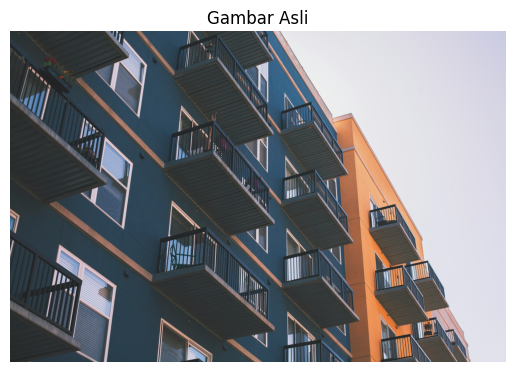

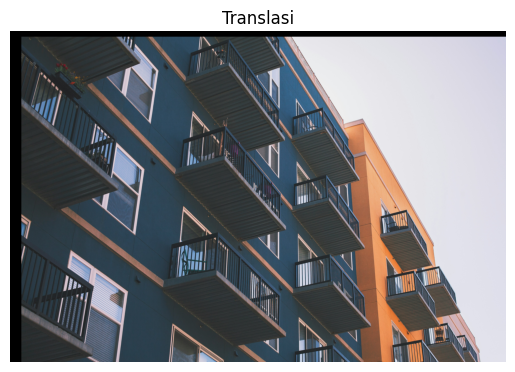

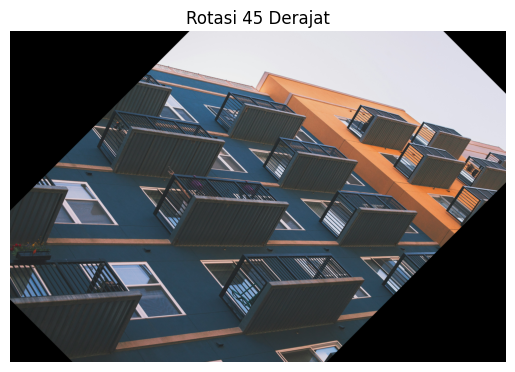

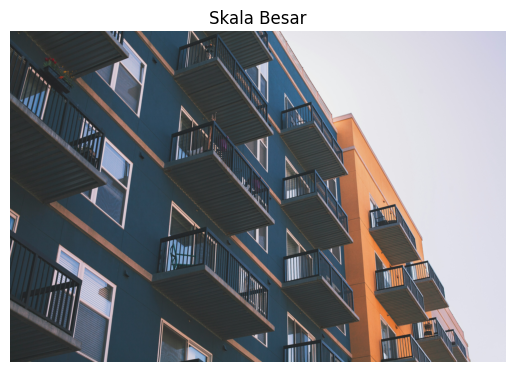

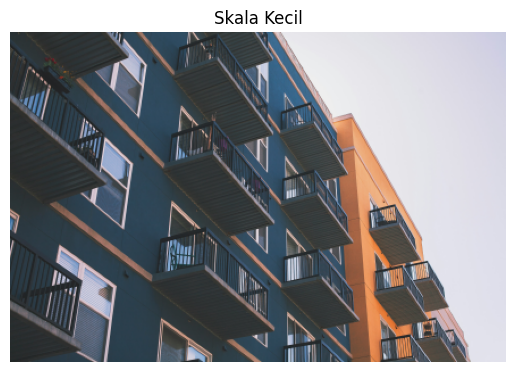

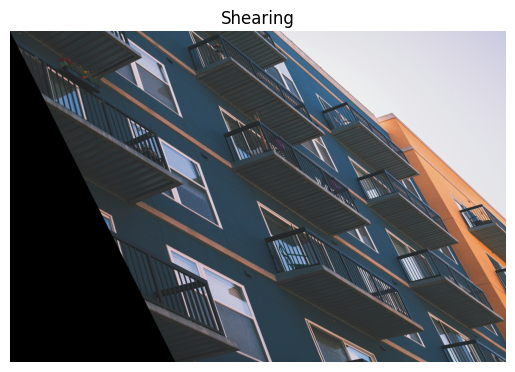

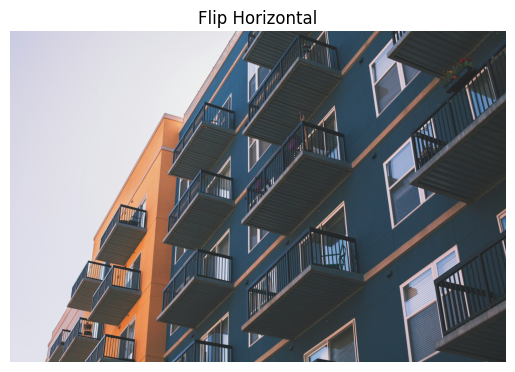

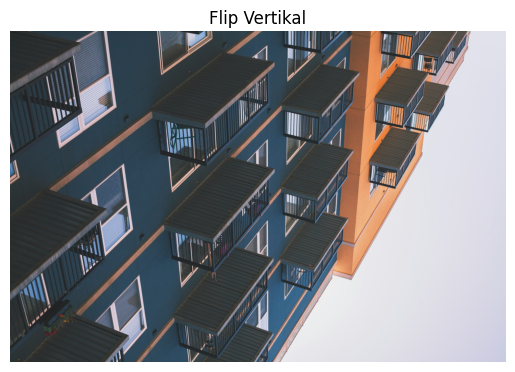

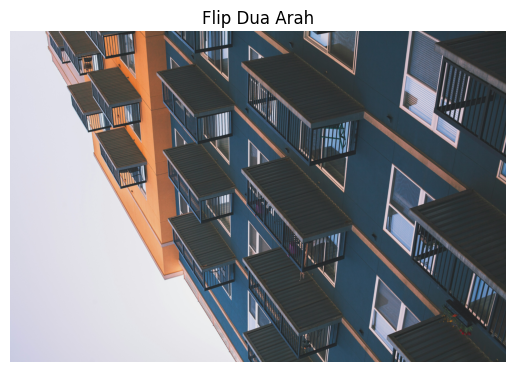

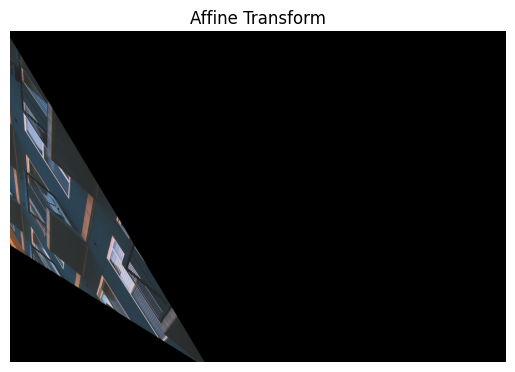

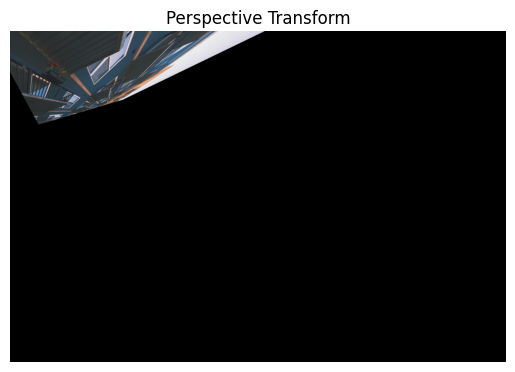

In [ ]:
# Tampilkan hasil dari Photo 1 sebagai contoh
print("=" * 60)
print("CONTOH HASIL TRANSFORMASI - PHOTO 1")
print("=" * 60)

# Baca Photo 1 original
img_sample = cv2.imread("Data Building Photo/Photo 1.jpg")
show("Photo 1 - Original", img_sample)

# Tampilkan hasil setiap transformasi untuk Photo 1
transformations = [
    ("Grayscale", "Result/Photo_1_grayscale.jpg"),
    ("Translasi", "Result/Photo_1_translasi.jpg"),
    ("Rotasi 45°", "Result/Photo_1_rotasi.jpg"),
    ("Scaling Besar", "Result/Photo_1_skala_besar.jpg"),
    ("Scaling Kecil", "Result/Photo_1_skala_kecil.jpg"),
    ("Shearing", "Result/Photo_1_shearing.jpg"),
    ("Flip Horizontal", "Result/Photo_1_flip_horizontal.jpg"),
    ("Flip Vertikal", "Result/Photo_1_flip_vertikal.jpg"),
    ("Affine Transform", "Result/Photo_1_affine.jpg"),
    ("Perspective Transform", "Result/Photo_1_perspektif.jpg"),
]

for title, path in transformations:
    if os.path.exists(path):
        result_img = cv2.imread(path)
        show(title, result_img)
    else:
        print(f"File tidak ditemukan: {path}")

print("\n✓ Semua 35 foto telah diproses dan disimpan di folder Result/")